# Load  Dataset

In [91]:
#import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
#assign the names to each columns
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]
#load the dataset and observe the first 10 rows
dataset=pd.read_csv(r"C:\Users\amity\SentinelNet\data\NSL-KDD\KDDTrain+.txt", header=None, names=columns)


## Explore Basic info:

In [93]:
dataset.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [94]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [95]:
print(dataset.describe())


       duration     src_bytes     dst_bytes      land  wrong_fragment  \
count 125973.00     125973.00     125973.00 125973.00       125973.00   
mean     287.14      45566.74      19779.11      0.00            0.02   
std     2604.52    5870331.18    4021269.15      0.01            0.25   
min        0.00          0.00          0.00      0.00            0.00   
25%        0.00          0.00          0.00      0.00            0.00   
50%        0.00         44.00          0.00      0.00            0.00   
75%        0.00        276.00        516.00      0.00            0.00   
max    42908.00 1379963888.00 1309937401.00      1.00            3.00   

         urgent       hot  num_failed_logins  logged_in  num_compromised  ...  \
count 125973.00 125973.00          125973.00  125973.00        125973.00  ...   
mean       0.00      0.20               0.00       0.40             0.28  ...   
std        0.01      2.15               0.05       0.49            23.94  ...   
min        0.00   

In [96]:
# Number of rows, columns
rows, cols = dataset.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 125973, Columns: 43


In [97]:
# Unique attack types
unique_attacks = dataset['label'].unique()
print("Unique attack types:", unique_attacks)

Unique attack types: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [98]:
# Top 5 frequent attacks
top_attacks = dataset['label'].value_counts().head(5)
print("Top 5 frequent attack types:\n", top_attacks)

Top 5 frequent attack types:
 label
normal       67343
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: count, dtype: int64


# Visualize Attack Distribution

## Bar chart of attack categories.

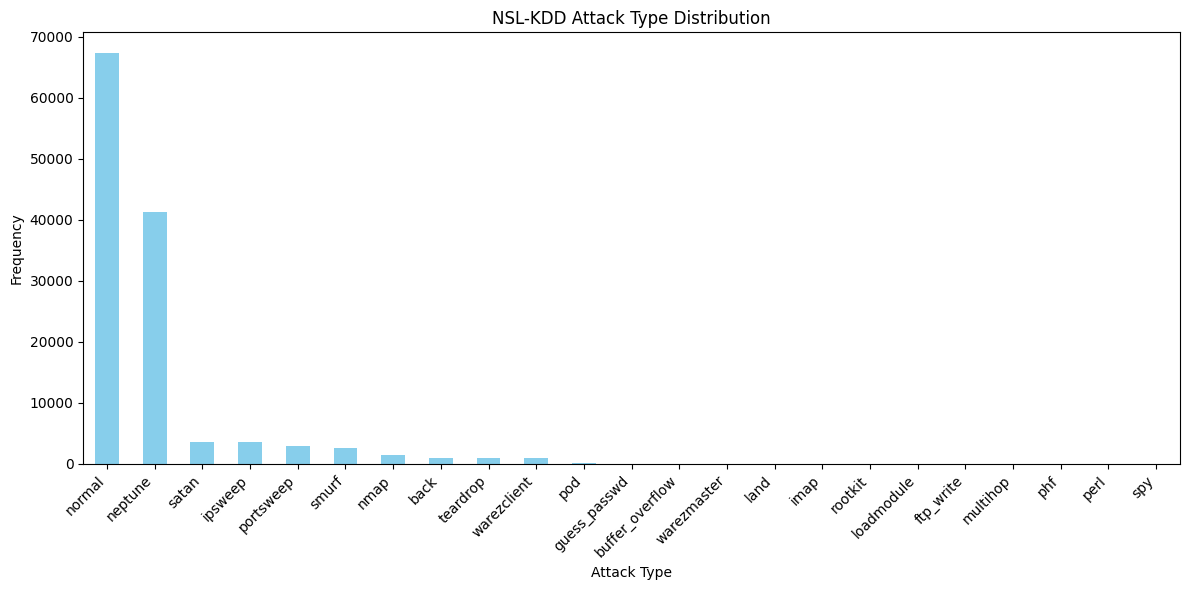

In [132]:
import matplotlib.pyplot as plt
import os

# Ensure the directory exists
save_dir = r"C:\Users\amity\SentinelNet\images"
os.makedirs(save_dir, exist_ok=True)

# Plot attack type distribution
plt.figure(figsize=(12,6))
dataset['label'].value_counts().plot(kind='bar', color='skyblue')
plt.title("NSL-KDD Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the plot
plt.savefig(os.path.join(save_dir, "nslkdd_attack_distribution.png"))

# Show the plot
plt.show()


# Pie Chart: Normal vs Attack Traffic

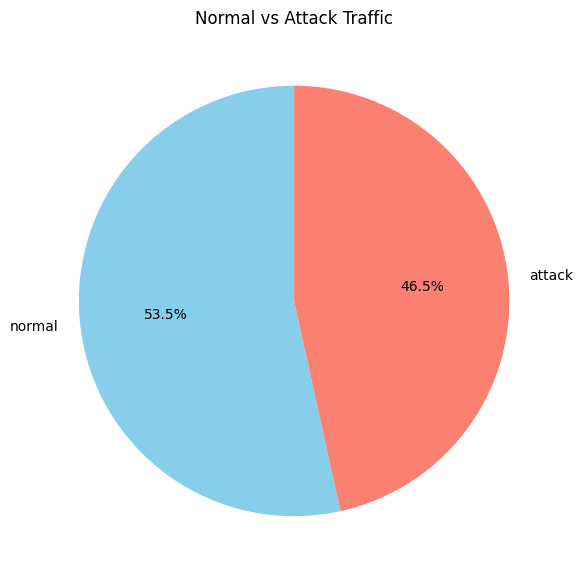

In [133]:
# Create a new column to classify normal vs attack
dataset['attack_type'] = dataset['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

plt.figure(figsize=(6,6))
dataset['attack_type'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90
)
plt.title("Normal vs Attack Traffic")
plt.ylabel('')  # Remove y-label for clarity
plt.tight_layout()

# Save the pie chart
save_dir = r"C:\Users\amity\SentinelNet\images"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "nslkdd_normal_vs_attack.png"))

# Show the pie chart
plt.show()


# Explore CICIDS2017 Dataset

In [101]:
# Load CICIDS2017 dataset
cicids_path = r"C:\Users\amity\SentinelNet\data\CICIDS2017\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
cicids_df = pd.read_csv(cicids_path)


In [102]:
print("CICIDS2017 Shape:", cicids_df.shape)

CICIDS2017 Shape: (170366, 79)


In [103]:
print(cicids_df.head())

    Destination Port   Flow Duration   Total Fwd Packets  \
0                389       113095465                  48   
1                389       113473706                  68   
2                  0       119945515                 150   
3                443        60261928                   9   
4                 53             269                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                       24                         9668   
1                       40                        11364   
2                        0                            0   
3                        7                         2330   
4                        2                          102   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                         10012                     403   
1                         12718                     403   
2                             0                       0   
3                          4221                 

In [104]:
print(cicids_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170366 entries, 0 to 170365
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             170366 non-null  int64  
 1    Flow Duration                170366 non-null  int64  
 2    Total Fwd Packets            170366 non-null  int64  
 3    Total Backward Packets       170366 non-null  int64  
 4   Total Length of Fwd Packets   170366 non-null  int64  
 5    Total Length of Bwd Packets  170366 non-null  int64  
 6    Fwd Packet Length Max        170366 non-null  int64  
 7    Fwd Packet Length Min        170366 non-null  int64  
 8    Fwd Packet Length Mean       170366 non-null  float64
 9    Fwd Packet Length Std        170366 non-null  float64
 10  Bwd Packet Length Max         170366 non-null  int64  
 11   Bwd Packet Length Min        170366 non-null  int64  
 12   Bwd Packet Length Mean       170366 non-nul

In [105]:
print(cicids_df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [106]:
# Compare number of features
print(f"NSL-KDD features: {dataset.shape[1]}, CICIDS2017 features: {cicids_df.shape[1]}")

NSL-KDD features: 44, CICIDS2017 features: 79


# Comparison Table (NSL-KDD vs CICIDS2017)

In [107]:
# Reload CICIDS2017 with correct encoding to fix "�"
cicids_path = r"C:\Users\amity\SentinelNet\data\CICIDS2017\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
cicids_df = pd.read_csv(cicids_path, encoding="latin1")  # fixes encoding issue

# Top 5 attacks for each dataset
nslkdd_top5 = dataset['label'].value_counts().head(5)
cicids_top5 = cicids_df[' Label'].value_counts().head(5)

# Function to format dict into bullet points...converts the dictionary into a string with bullet points
def format_top_attacks(attack_dict):
    return "\n".join([f"- {k}: {v}" for k, v in attack_dict.items()])

# Build comparison data
comparison_data = {
    "Dataset": ["NSL-KDD", "CICIDS2017"],
    "Rows": [dataset.shape[0], cicids_df.shape[0]],
    "Columns": [dataset.shape[1], cicids_df.shape[1]],
    "Unique Attacks": [len(dataset['label'].unique()), cicids_df[' Label'].nunique()],
    "Top 5 Attacks": [
        format_top_attacks(nslkdd_top5.to_dict()),
        format_top_attacks(cicids_top5.to_dict())
    ]
}

# Create DataFrame
comparison_table = pd.DataFrame(comparison_data)

# Display nicely......using jinja2 python package
comparison_table.style.set_properties(**{
    'white-space': 'pre-wrap',
    'text-align': 'left'
})


,Dataset,Rows,Columns,Unique Attacks,Top 5 Attacks
0,NSL-KDD,125973,44,23,- normal: 67343 - neptune: 41214 - satan: 3633 - ipsweep: 3599 - portsweep: 2931
1,CICIDS2017,170366,79,4,- BENIGN: 168186 - Web Attack ï¿½ Brute Force: 1507 - Web Attack ï¿½ XSS: 652 - Web Attack ï¿½ Sql Injection: 21


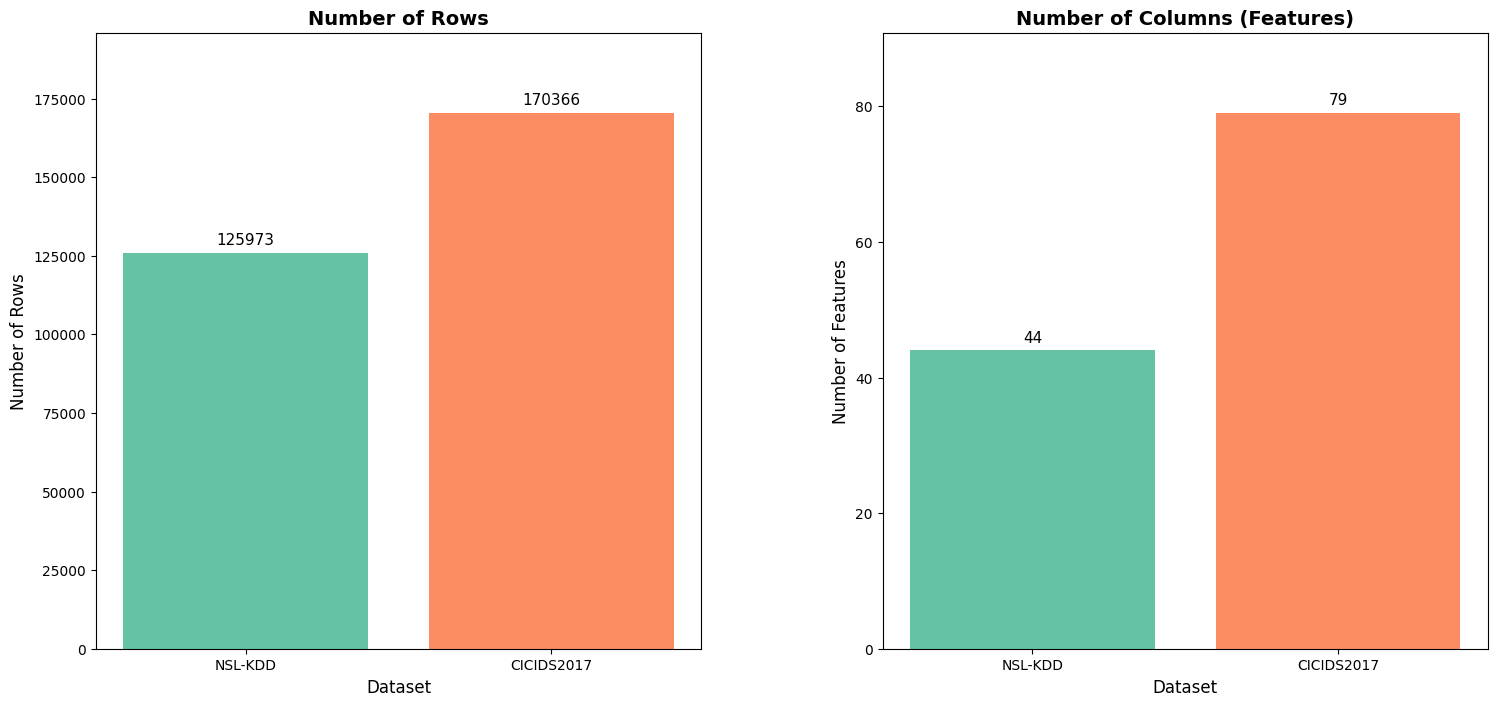

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure directory exists
save_dir = r"C:\Users\amity\SentinelNet\images"
os.makedirs(save_dir, exist_ok=True)

# Use Set2 palette
colors = sns.color_palette("Set2", n_colors=len(comparison_table))

# Make figure wider and taller
fig, ax = plt.subplots(1, 2, figsize=(16,8))  # taller now

# Bar chart: Number of Rows
bars_rows = ax[0].bar(comparison_table['Dataset'], comparison_table['Rows'], color=colors)
ax[0].set_title('Number of Rows', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Dataset', fontsize=12)
ax[0].set_ylabel('Number of Rows', fontsize=12)
ax[0].set_ylim(0, max(comparison_table['Rows'])*1.15)  # y-limit
for bar in bars_rows:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, height + 0.01*max(comparison_table['Rows']),
               f'{int(height)}', ha='center', va='bottom', fontsize=11)

# Bar chart: Number of Columns (Features)
bars_cols = ax[1].bar(comparison_table['Dataset'], comparison_table['Columns'], color=colors)
ax[1].set_title('Number of Columns (Features)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Dataset', fontsize=12)
ax[1].set_ylabel('Number of Features', fontsize=12)
ax[1].set_ylim(0, max(comparison_table['Columns'])*1.15)  # y-limit
for bar in bars_cols:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height + 0.01*max(comparison_table['Columns']),
               f'{int(height)}', ha='center', va='bottom', fontsize=11)

# Remove grid lines
ax[0].grid(False)
ax[1].grid(False)

# Adjust layout
plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.15, wspace=0.3)

# Save figure in images directory
plt.savefig(os.path.join(save_dir, "nsl_kdd_dataset_comparison.png"), dpi=300)

# Show plot
plt.show()


##  Preprocessing

In [109]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

In [110]:
# 1. Drop duplicate rows
dataset = dataset.drop_duplicates()

In [111]:
# 2. Handle missing values (NSL-KDD has none, but safer to fill if any)
dataset = dataset.fillna(0)

In [112]:
# 3. Drop unnecessary columns
dataset = dataset.drop(columns=['difficulty_level'], errors='ignore')

In [113]:
print(dataset.columns.tolist())


['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'attack_type']


In [114]:
# 4. Encode categorical features // does not need as already encoded or droped
categorical_cols = ['protocol_type', 'service', 'flag']
dataset = pd.get_dummies(dataset, columns=categorical_cols)

In [115]:
# 5. Encode labels
# Binary label: normal=0, attack=1
dataset['binary_label'] = dataset['label'].apply(lambda x: 0 if x == 'normal' else 1)
# Multi-class label: keep original attack names
dataset['multi_label'] = dataset['label']

In [116]:
# 6. Remove original labels from features
X = dataset.drop(columns=['label', 'binary_label', 'multi_label', 'attack_type'], errors='ignore')
y_binary = dataset['binary_label']
y_multi = dataset['multi_label']

In [117]:
# 7. Identify numeric columns for scaling
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

In [118]:
# 8. Scale numeric features
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [146]:
import os
import joblib
import pandas as pd

# Directory to save processed NSL-KDD data
save_path = r"C:\Users\amity\SentinelNet\data\processed\nsl_kdd"
os.makedirs(save_path, exist_ok=True)

# 1️⃣ Save full processed dataset
dataset.to_csv(os.path.join(save_path, "nslkdd_processed.csv"), index=False)

# 2️⃣ Save X (features) and y_binary
# You can optionally select features like CICIDS2017, or save all numeric features
X_selected = X_scaled.copy()  # you may also select columns if you have feature selection
X_selected_df = pd.DataFrame(X_selected, columns=X_selected.columns)
X_selected_df['Label'] = y_binary.values
X_selected_df.to_csv(os.path.join(save_path, "X_selected.csv"), index=False)

# 3️⃣ Save as .pkl for fast loading
joblib.dump(X_selected, os.path.join(save_path, "X_selected.pkl"))
joblib.dump(y_binary.values, os.path.join(save_path, "y_binary.pkl"))

print("✅ NSL-KDD processed data saved successfully in:", save_path)


✅ NSL-KDD processed data saved successfully in: C:\Users\amity\SentinelNet\data\processed\nsl_kdd


## 

## Train test and split

In [121]:
from sklearn.model_selection import train_test_split

# Step 1: Split into train+val (80%) and test (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

# Step 2: Split train+val into train (60%) and validation (20%)
# 0.25 of 80% = 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Check non-numeric columns (should be 0 after one-hot encoding)
print("Non-numeric columns in X_train:", X_train.select_dtypes(include=['object','bool']).columns.tolist())

# Print shapes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Non-numeric columns in X_train: ['protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'service_echo', 'service_eco_i', 'service_ecr_i', 'service_efs', 'service_exec', 'service_finger', 'service_ftp', 'service_ftp_data', 'service_gopher', 'service_harvest', 'service_hostnames', 'service_http', 'service_http_2784', 'service_http_443', 'service_http_8001', 'service_imap4', 'service_iso_tsap', 'service_klogin', 'service_kshell', 'service_ldap', 'service_link', 'service_login', 'service_mtp', 'service_name', 'service_netbios_dgm', 'service_netbios_ns', 'service_netbios_ssn', 'service_netstat', 'service_nnsp', 'service_nntp', 'service_ntp_u', 'service_other', 'service_pm_dump', 'service_pop_2', 'service_pop_3', 'service_printer', 'service_private', 'service_red

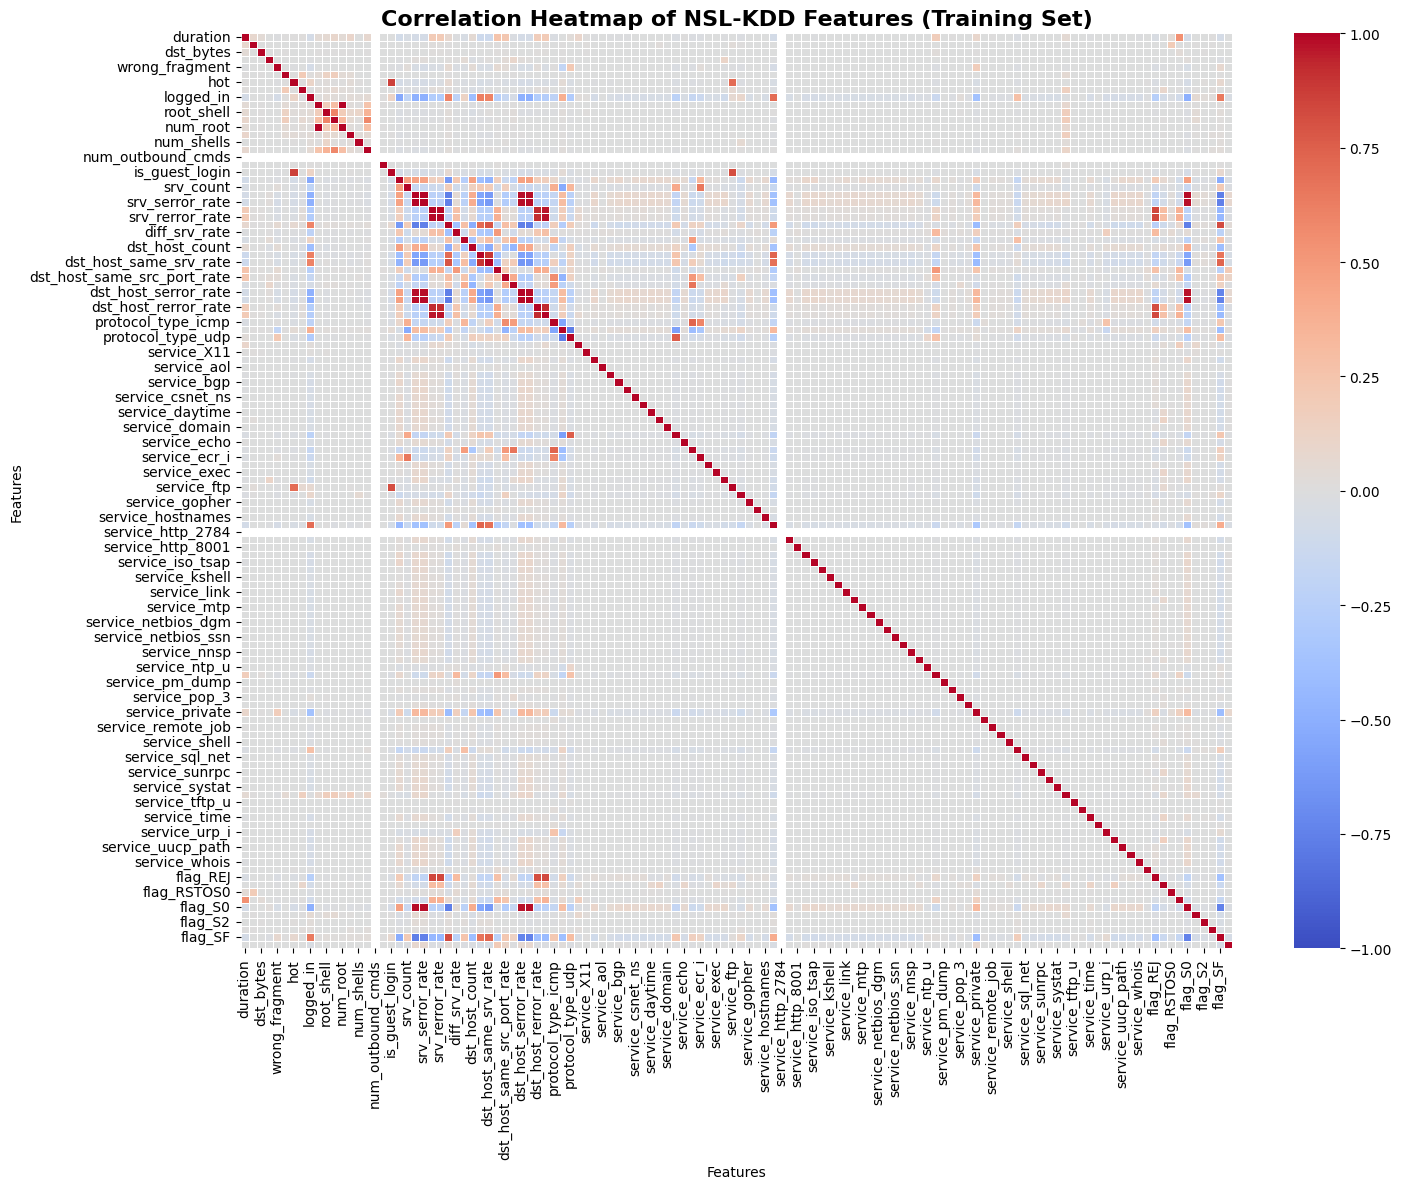

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure save directory exists
save_dir = r"C:\Users\amity\SentinelNet\images"
os.makedirs(save_dir, exist_ok=True)

# Compute correlation matrix for training set
corr_matrix = X_train.corr()

# Set figure size
plt.figure(figsize=(15,12))

# Plot heatmap
sns.heatmap(
    corr_matrix,
    annot=False,        # Set True if you want correlation values inside cells
    cmap='coolwarm',    # Color palette
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title("Correlation Heatmap of NSL-KDD Features (Training Set)", fontsize=16, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()

# Save the heatmap
plt.savefig(os.path.join(save_dir, "nslkdd_correlation_heatmap.png"), dpi=300)

# Show the plot
plt.show()


In [123]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define models
# Define models with hyperparameter tweaks
# Define models with hyperparameter tweaks
models = {
    "Random Forest": RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    min_samples_split=50,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    min_samples_split=50,
    class_weight='balanced',
    random_state=42
),


    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_depth=6,
    min_samples_leaf=20,
    learning_rate=0.05,
    max_iter=200,
    l2_regularization=0.1,
    early_stopping=True,
    random_state=42
)
}

# Initialize results list
results = []



In [124]:
for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict on train, validation, and test sets
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Compute accuracies
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    val_acc = accuracy_score(y_val, y_val_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100
    
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    
    # Store predictions in results for later metrics
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc,
        "y_test_pred": y_test_pred,
        "model_obj": model
    })



=== Random Forest ===
Train Accuracy: 98.69%
Validation Accuracy: 98.57%
Test Accuracy: 98.56%

=== Logistic Regression ===
Train Accuracy: 97.30%
Validation Accuracy: 97.37%
Test Accuracy: 97.11%

=== Decision Tree ===
Train Accuracy: 99.30%
Validation Accuracy: 99.24%
Test Accuracy: 99.32%

=== HistGradientBoosting ===
Train Accuracy: 99.93%
Validation Accuracy: 99.83%
Test Accuracy: 99.87%


In [138]:
import joblib
import os

# Directory to save models
save_dir = r"C:\Users\amity\SentinelNet\app\models\nsl_kdd_models"
os.makedirs(save_dir, exist_ok=True)

# Save each trained model silently
for r in results:
    model = r['model_obj']
    model_name = r['Model'].replace(' ', '_').lower()
    filename = os.path.join(save_dir, f"{model_name}.pkl")
    joblib.dump(model, filename)

# Save scaler
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))


['C:\\Users\\amity\\SentinelNet\\app\\models\\nsl_kdd_models\\scaler.pkl']

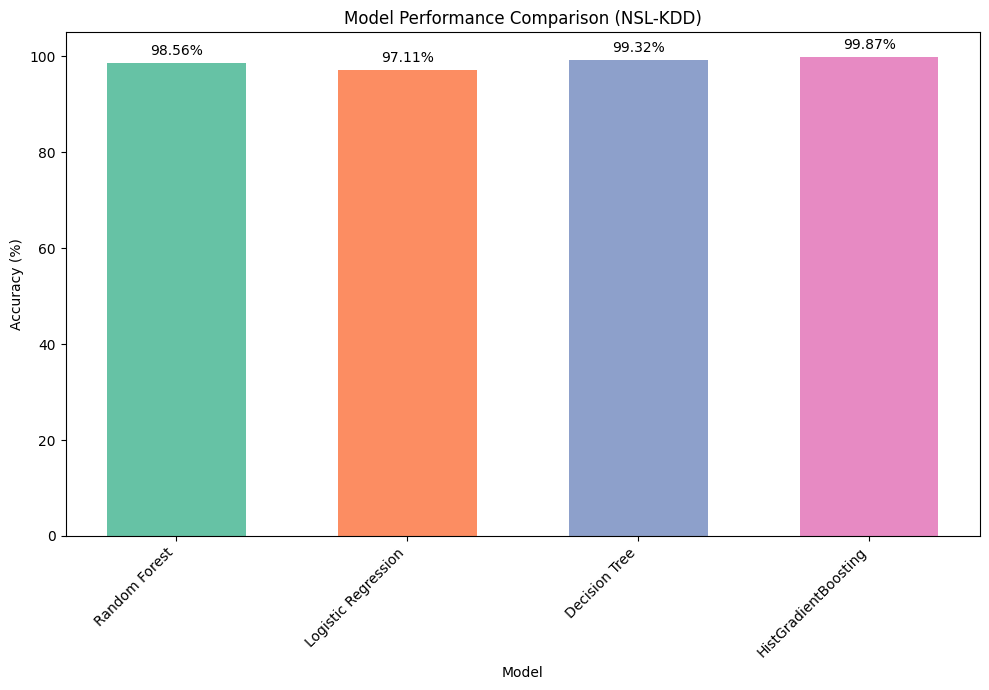

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Ensure the directory exists
save_dir = r"C:\Users\amity\SentinelNet\images"
os.makedirs(save_dir, exist_ok=True)

# Prepare data
model_names = [r['Model'] for r in results]
test_acc = [r['Test Accuracy'] for r in results]

x = np.arange(len(model_names))  # label locations
width = 0.6  # bar width

# Use Seaborn Set2 color palette
colors = sns.color_palette("Set2", n_colors=len(model_names))

plt.figure(figsize=(10,7))
bars = plt.bar(x, test_acc, width, color=colors)

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.xticks(x, model_names, rotation=45, ha='right')
plt.ylim(0, 105)
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Performance Comparison (NSL-KDD)")
plt.grid(False)
plt.tight_layout()

# Save the figure
save_path = os.path.join(save_dir, "nsl_kdd_model_performance_comparison.png")
plt.savefig(save_path, dpi=300)

plt.show()



=== Random Forest ===
Train Accuracy: 98.69%
Validation Accuracy: 98.57%
Test Accuracy: 98.56%


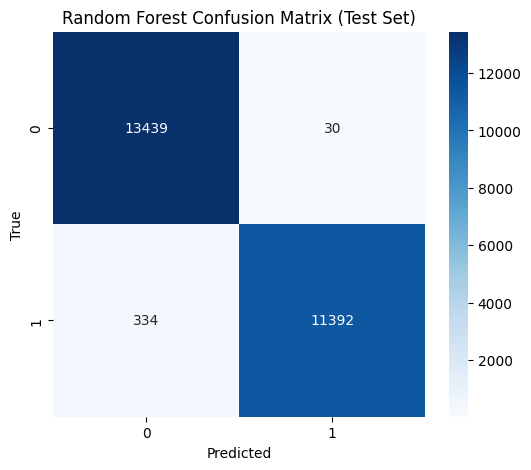


=== Logistic Regression ===
Train Accuracy: 97.30%
Validation Accuracy: 97.37%
Test Accuracy: 97.11%


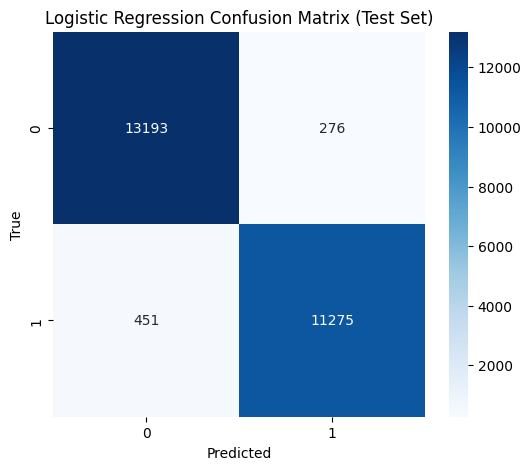


=== Decision Tree ===
Train Accuracy: 99.30%
Validation Accuracy: 99.24%
Test Accuracy: 99.32%


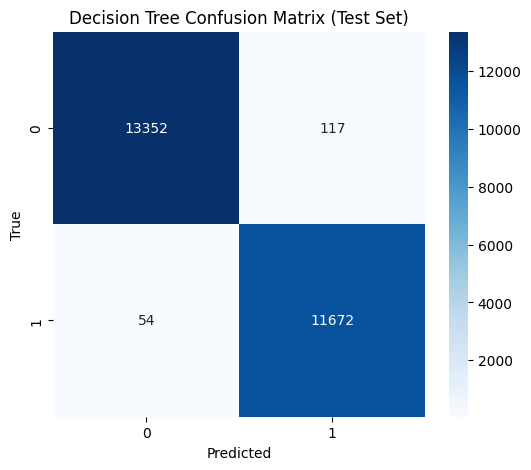


=== HistGradientBoosting ===
Train Accuracy: 99.93%
Validation Accuracy: 99.83%
Test Accuracy: 99.87%


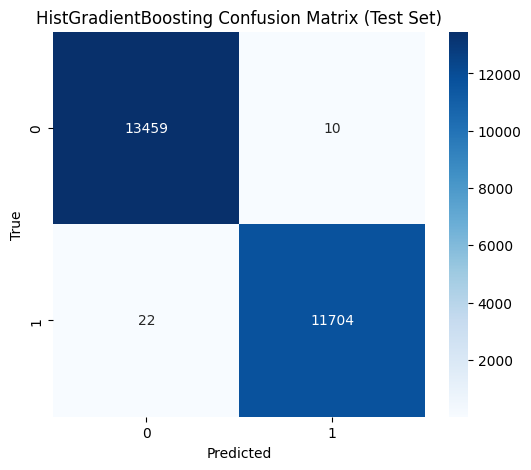

In [140]:
for r in results:
    model = r['model_obj']
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = r['y_test_pred']
    
    # Compute accuracies
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    val_acc = accuracy_score(y_val, y_val_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100
    
    # Print accuracies
    print(f"\n=== {r['Model']} ===")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{r['Model']} Confusion Matrix (Test Set)")
    plt.show()


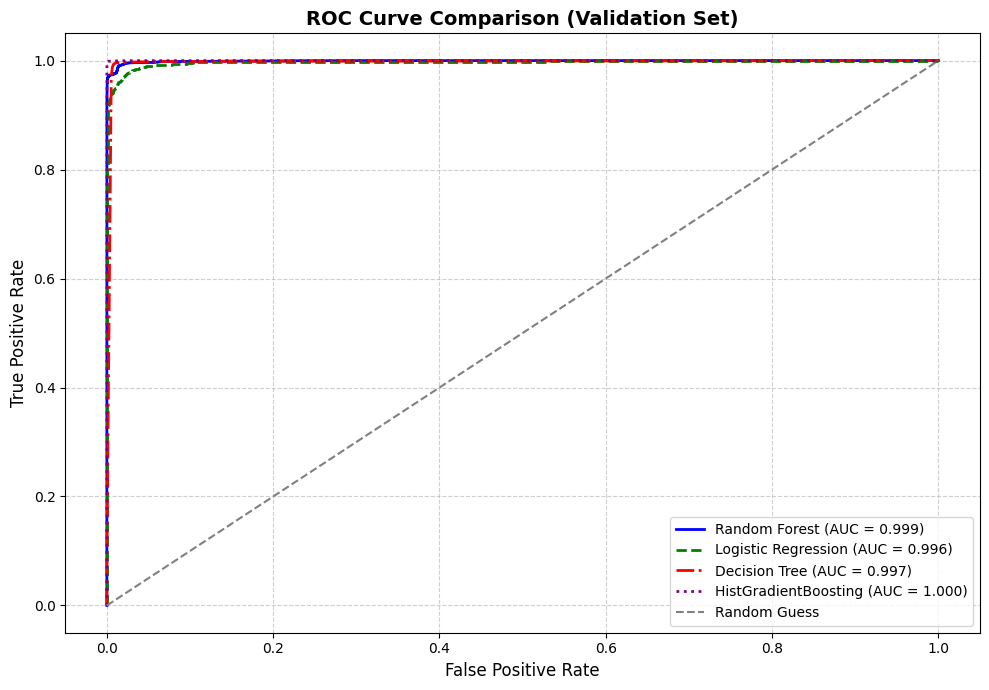

In [144]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define colors and line styles for clarity
colors = ['blue', 'green', 'red', 'purple']
linestyles = ['-', '--', '-.', ':']

# ---- ROC Curve for Validation Set ----
plt.figure(figsize=(10,7))
for i, r in enumerate(results):
    model = r['model_obj']
    try:
        y_val_prob = model.predict_proba(X_val)[:,1]
    except AttributeError:
        print(f"{r['Model']} does not support predict_proba, skipping ROC for validation.")
        continue
    
    fpr, tpr, _ = roc_curve(y_val, y_val_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], linestyle=linestyles[i % len(linestyles)],
             linewidth=2, label=f"{r['Model']} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison (Validation Set)", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


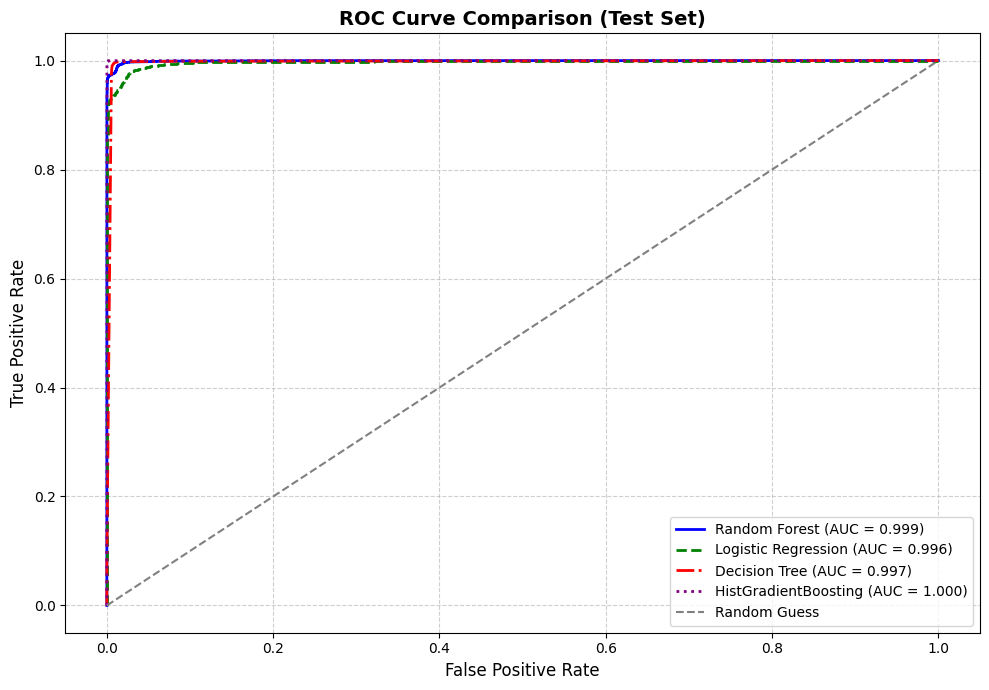

In [145]:

# ---- ROC Curve for Test Set ----
plt.figure(figsize=(10,7))
for i, r in enumerate(results):
    model = r['model_obj']
    try:
        y_test_prob = model.predict_proba(X_test)[:,1]
    except AttributeError:
        print(f"{r['Model']} does not support predict_proba, skipping ROC for test.")
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], linestyle=linestyles[i % len(linestyles)],
             linewidth=2, label=f"{r['Model']} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison (Test Set)", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

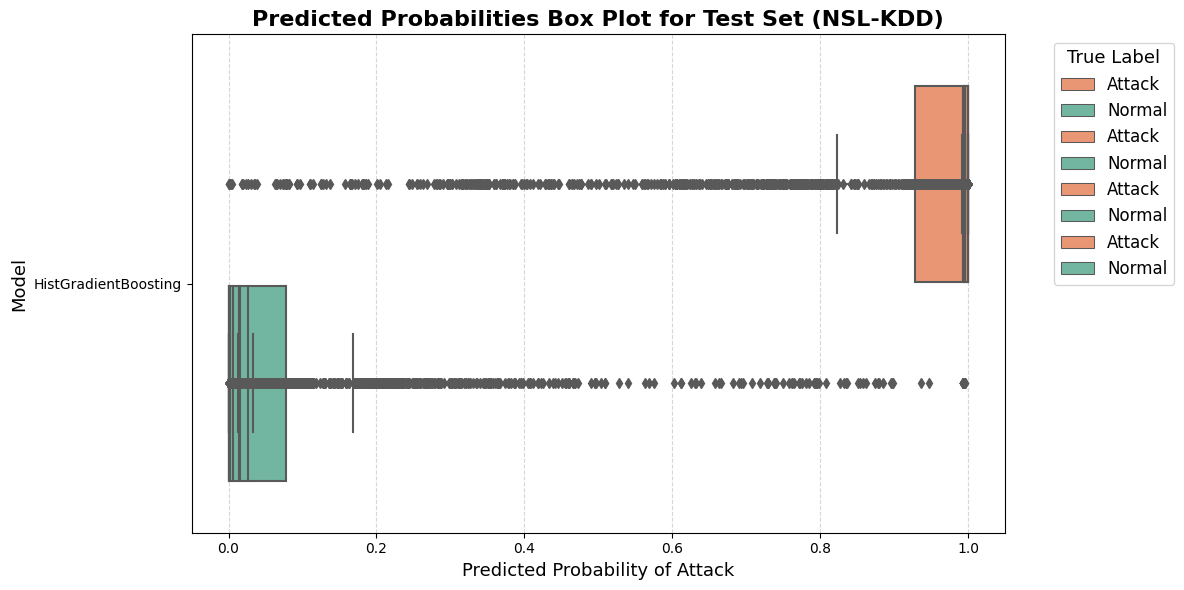

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(12,6))

# Use Seaborn Set2 color palette for True Labels
palette_colors = sns.color_palette("Set2", 2)  # 2 colors: Normal, Attack

# Map labels to colors
label_palette = {'Normal': palette_colors[0], 'Attack': palette_colors[1]}

# Loop through each model
for r in results:
    model = r['model_obj']
    try:
        y_test_prob = model.predict_proba(X_test)[:,1]  # probability of Attack
    except AttributeError:
        continue  # skip models without predict_proba
    
    # Prepare DataFrame for plotting
    df_plot = pd.DataFrame({
        'Predicted Probability': y_test_prob,
        'True Label': y_test.map({0:'Normal', 1:'Attack'})
    })
    
    # Horizontal box plot for this model
    sns.boxplot(
        data=df_plot,
        x='Predicted Probability',
        y=pd.Series([r['Model']]*len(df_plot)),  # horizontal orientation
        hue='True Label',
        orient='h',
        palette=label_palette
    )

plt.title("Predicted Probabilities Box Plot for Test Set (NSL-KDD)", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Probability of Attack", fontsize=13)
plt.ylabel("Model", fontsize=13)
plt.legend(title='True Label', fontsize=12, title_fontsize=13, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Compute sensitivity, specificity, precision, F1, AUC

In [130]:
for r in results:
    cm = confusion_matrix(y_test, r['y_test_pred'])
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn) * 100
    specificity = tn / (tn + fp) * 100
    precision = precision_score(y_test, r['y_test_pred']) * 100
    f1 = f1_score(y_test, r['y_test_pred']) * 100
    try:
        y_test_prob = r['model_obj'].predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_test_prob) * 100
    except AttributeError:
        auc = None
    
    # Update results dict
    r.update({
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1-Score": f1,
        "AUC": auc
    })
     # Print metrics for this model
    print(f"\n=== {r['Model']} Metrics ===")
    print(f"Sensitivity (Recall): {sensitivity:.2f}%")
    print(f"Specificity: {specificity:.2f}%")
    print(f"Precision: {precision:.2f}%")
    print(f"F1-Score: {f1:.2f}%")
    if auc is not None:
        print(f"AUC: {auc:.2f}%")



=== Random Forest Metrics ===
Sensitivity (Recall): 97.15%
Specificity: 99.78%
Precision: 99.74%
F1-Score: 98.43%
AUC: 99.94%

=== Logistic Regression Metrics ===
Sensitivity (Recall): 96.15%
Specificity: 97.95%
Precision: 97.61%
F1-Score: 96.88%
AUC: 99.64%

=== Decision Tree Metrics ===
Sensitivity (Recall): 99.54%
Specificity: 99.13%
Precision: 99.01%
F1-Score: 99.27%
AUC: 99.67%

=== HistGradientBoosting Metrics ===
Sensitivity (Recall): 99.81%
Specificity: 99.93%
Precision: 99.91%
F1-Score: 99.86%
AUC: 100.00%


In [131]:
summary_df = pd.DataFrame(results).drop(columns=['y_test_pred','model_obj'])
pd.set_option('display.float_format', '{:.2f}'.format)
print("\n=== NSL-KDD Summary Table ===")
summary_df



=== NSL-KDD Summary Table ===


,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Sensitivity (Recall),Specificity,Precision,F1-Score,AUC
0,Random Forest,98.69,98.57,98.56,97.15,99.78,99.74,98.43,99.94
1,Logistic Regression,97.30,97.37,97.11,96.15,97.95,97.61,96.88,99.64
2,Decision Tree,99.30,99.24,99.32,99.54,99.13,99.01,99.27,99.67
3,HistGradientBoosting,99.93,99.83,99.87,99.81,99.93,99.91,99.86,100.00
